# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [8]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
import xgboost
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [12]:
data = pd.read_csv (r'data\comprar_alquilar.csv')

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


In [14]:
# 9 variables. Sin nulos. Todo variables numéricas

In [15]:
data.describe()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

In [16]:
data.columns

Index(['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros',
       'vivienda', 'estado_civil', 'hijos', 'trabajo', 'comprar'],
      dtype='object')

In [17]:
# Separo las variables que son numéricas continuas
col_num =['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros',
       'vivienda']
# De las que son numéricas pero que reflejan una categoría (son valores discretos)
col_cat =['estado_civil', 'hijos', 'trabajo']


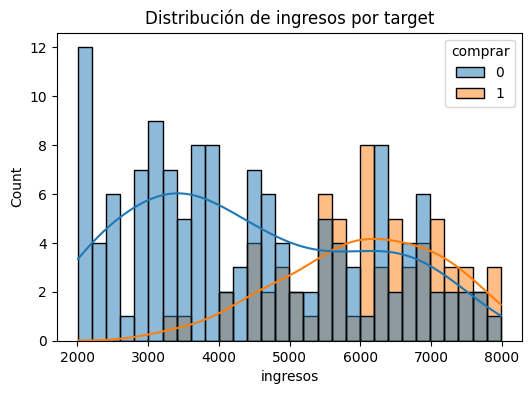

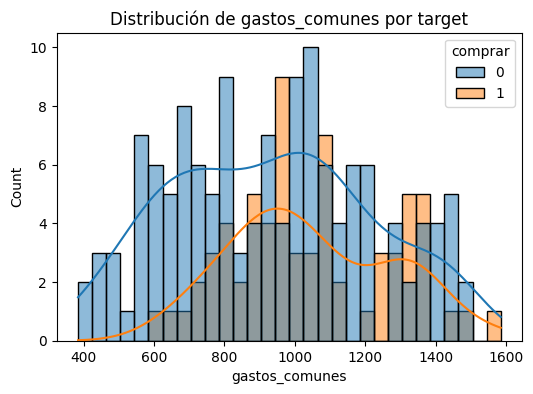

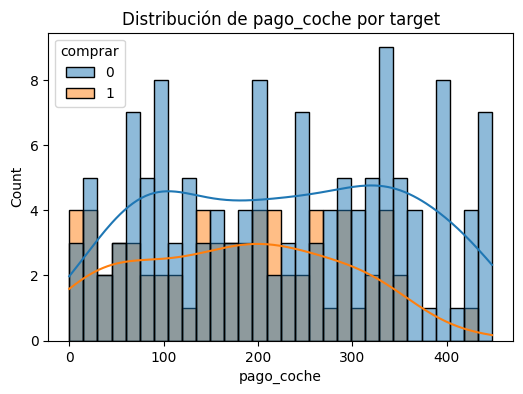

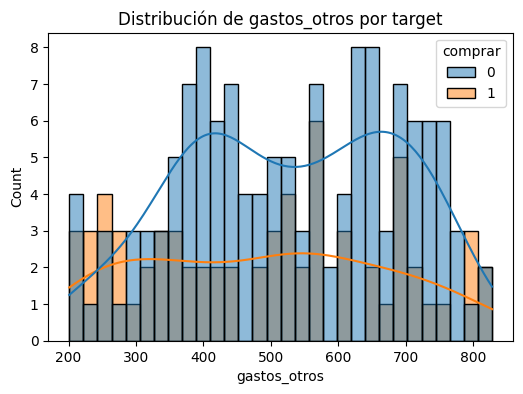

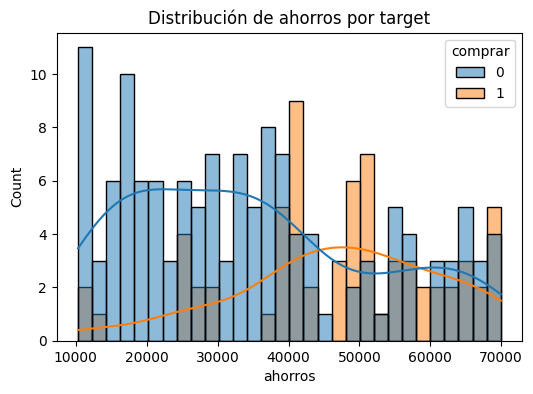

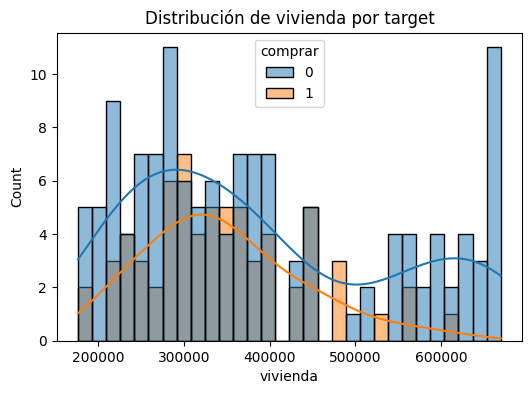

In [18]:
# Para las numéricas en un histograma a ver cómo se relacionan con el target
for col in col_num:
    plt.figure(figsize=(6,4))
    sns.histplot(data=data, x=col, hue='comprar', kde=True, bins=30)
    plt.title(f'Distribución de {col} por target')
    plt.show()

In [19]:
#Ingresos y ahorros parecen las variables que mejor diferencian el target según estos gráficos

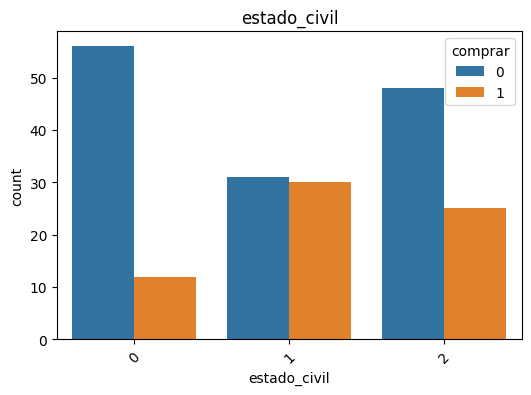

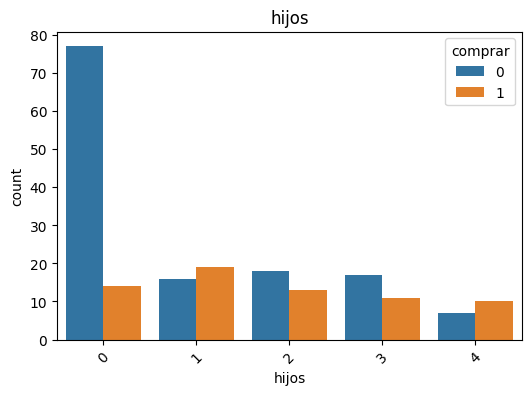

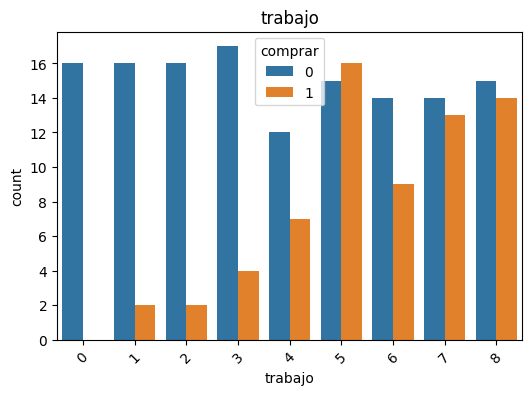

In [20]:
for col in col_cat:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x=col, hue='comprar')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [21]:
data.columns

Index(['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros',
       'vivienda', 'estado_civil', 'hijos', 'trabajo', 'comprar'],
      dtype='object')

In [22]:
X = data.drop(columns= 'comprar')
scaler = StandardScaler()
data_scal = scaler.fit_transform(X)

## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [23]:
model_pca9 = PCA (9)
X_pca = model_pca9.fit_transform(data_scal)

### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [24]:
model_pca9.explained_variance_ratio_

array([0.29913557, 0.23294923, 0.11711241, 0.10685622, 0.09635279,
       0.05629866, 0.04145579, 0.03017819, 0.01966115])

In [25]:
var_acumulada=model_pca9.explained_variance_ratio_.cumsum()
var_acumulada

array([0.29913557, 0.5320848 , 0.64919721, 0.75605343, 0.85240621,
       0.90870487, 0.95016066, 0.98033885, 1.        ])

In [26]:
#El 85 por ciento de la varianza queda explicada con los primeros 5 PCs

In [27]:
import pandas as pd

df_varianza = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(model_pca9.explained_variance_ratio_))],
    'Varianza_explicada': model_pca9.explained_variance_ratio_,
    'Varianza_acumulada': model_pca9.explained_variance_ratio_.cumsum()
})

df_varianza

,PC,Varianza_explicada,Varianza_acumulada
0,PC1,0.299136,0.299136
1,PC2,0.232949,0.532085
2,PC3,0.117112,0.649197
3,PC4,0.106856,0.756053
4,PC5,0.096353,0.852406
5,PC6,0.056299,0.908705
6,PC7,0.041456,0.950161
7,PC8,0.030178,0.980339
8,PC9,0.019661,1.000000


### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

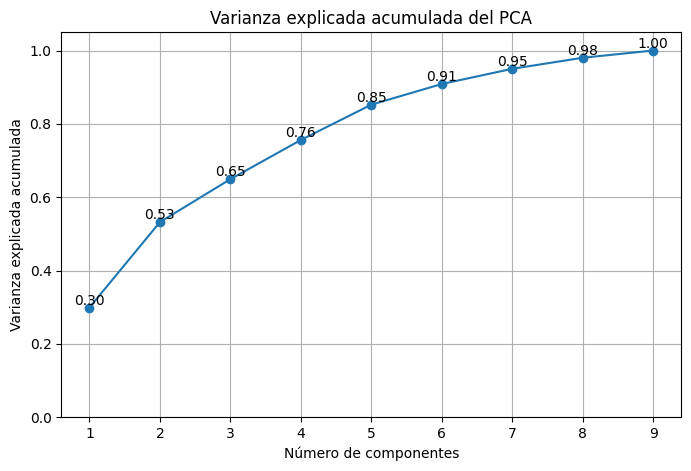

In [28]:
#En gráfico
plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_acumulada) + 1), var_acumulada, marker='o')

# Añadir valores en cada punto
for i, v in enumerate(var_acumulada):
    plt.text(i+1, v, f'{v:.2f}', ha='center', va='bottom')

plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada del PCA')

plt.ylim(0, 1.05)
plt.grid(True)

plt.show()

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

In [36]:
contribucionPCs = model_pca9.components_
data =data.drop(columns='comprar')
originales = data.columns


In [37]:
df_contribuciones = pd.DataFrame(
    contribucionPCs,
    originales
)
df_contribuciones.index = [f'PC{i+1}' for i in range(df_contribuciones.shape[0])]

In [ ]:
df_contribuciones
# He intentado que los nombbres sean los de las variables originales pero en algún punto los he perdido.

,0,1,2,3,4,5,6,7,8
PC1,0.493720,0.318229,-0.123771,-0.111876,0.444650,0.462609,-0.252279,-0.259859,-0.290248
PC2,0.306959,0.147373,-0.091641,0.000112,0.288435,0.148985,0.469044,0.521894,0.527156
PC3,-0.091419,-0.363453,-0.516144,0.701986,0.191767,0.140513,-0.172885,0.112184,-0.036910
PC4,0.111222,0.081630,0.780268,0.590704,0.022839,0.150085,-0.007663,0.007404,-0.007493
PC5,0.088897,0.763006,-0.265554,0.330744,-0.289002,-0.365556,-0.104639,0.043668,0.000009
PC6,-0.075477,0.067903,-0.153697,0.154422,-0.230181,0.290799,0.767070,-0.387964,-0.256446
PC7,-0.154319,0.105598,-0.027333,-0.101876,-0.524584,0.641034,-0.212365,0.460067,-0.105053
PC8,-0.012732,0.010274,-0.061759,0.037977,-0.212759,0.260847,-0.204816,-0.532216,0.745630
PC9,0.776990,-0.374440,-0.048557,0.026631,-0.474168,-0.156101,-0.003289,0.011051,-0.060657


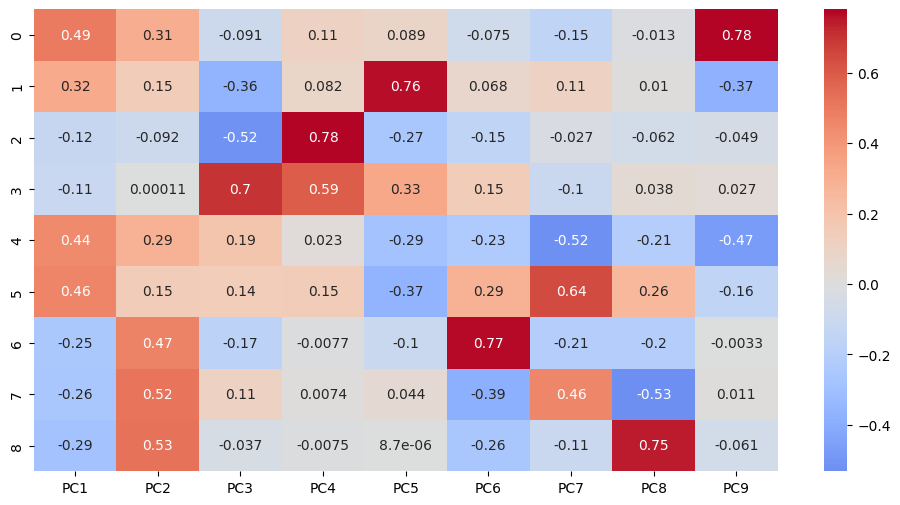

In [39]:
plt.figure(figsize=(12,6))
sns.heatmap(df_contribuciones.T, annot=True, cmap='coolwarm', center=0)
plt.show()

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

In [ ]:
# 1 Lo vuelvo a cargar que me había quitado columnas
data_2 = pd.read_csv (r'data\comprar_alquilar.csv')
X = data_2.drop(columns='comprar')
y = data_2['comprar']

# Separo datos. OJO, clases muy desbalanceadas. Meter stratify = y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 2 Creo el pipeline con un XGBoost de clasificador
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),      
    ('pca', PCA(n_components=5)),       
    ('classifier', xgboost.XGBClassifier())     
])

In [48]:
# 3 Entreno
pipeline_xgb.fit(X_train, y_train)

# 4 Predicción
predicciones = pipeline_xgb.predict(X_test)

# 5 Evaluar el rendimiento en train y test
score = pipeline_xgb.score(X_train, y_train)
print(f"Precisión del pipeline train: {score:.2f}")
score = pipeline_xgb.score(X_test, y_test)
print(f"Precisión del pipeline test: {score:.2f}")

Precisión del pipeline train: 1.00
Precisión del pipeline test: 0.73


In [ ]:
# 1 en train?? Parece que tiene muchísimo overfit!

In [ ]:
conf_matrix = confusion_matrix (y_true=y_test, y_pred=predicciones)
conf_matrix

#Filas en 

array([[21,  3],
       [ 8,  9]])

In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'pca__n_components': [5, 7, 9],                 
    'classifier__n_estimators': [50, 100],          
    'classifier__max_depth': [3, 5, 7],             
    'classifier__learning_rate': [0.01, 0.1],       
    'classifier__subsample': [0.8]                  
}


# Aunque hayamos separado en train test con stratify aquí hay que meterlo también. Mirar como
# Creo que con KFold o no se qué (Claude o preguntar a Unai)
grid_search = GridSearchCV(pipeline_xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)


grid_search.fit(X_train, y_train)

# Mejores resultados
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor Accuracy en crossvalidation: {grid_search.best_score_:.2f}")

# Evaluar el mejor modelo en test
best_model = grid_search.best_estimator_
print(f"Accuracy final en Test: {best_model.score(X_test, y_test):.2f}")

Mejores parámetros: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 50, 'classifier__subsample': 0.8, 'pca__n_components': 7}
Mejor Accuracy en crossvalidation: 0.86
Accuracy final en Test: 0.83


In [53]:
# Guardamos el mejor modelo
import pickle
with open('PCA_alquiler_compra_best', 'wb') as f:
    pickle.dump(best_model, f)